In [30]:
# .- Se realizan las importaciones de librerías respectivas y a utilizar.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests


In [31]:
df = pd.read_csv('dataset_car_seats.csv')

In [32]:
display(df)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4,4.15,141,64,3,340,128,Bad,38,13,Yes,No
...,...,...,...,...,...,...,...,...,...,...,...,...
395,395,12.57,138,108,17,203,128,Good,33,14,Yes,Yes
396,396,6.14,139,23,3,37,120,Medium,55,11,No,Yes
397,397,7.41,162,26,12,368,159,Medium,40,18,Yes,Yes
398,398,5.94,100,79,7,284,95,Bad,50,12,Yes,Yes


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   400 non-null    int64  
 1   Sales        400 non-null    float64
 2   CompPrice    400 non-null    int64  
 3   Income       400 non-null    int64  
 4   Advertising  400 non-null    int64  
 5   Population   400 non-null    int64  
 6   Price        400 non-null    int64  
 7   ShelveLoc    400 non-null    object 
 8   Age          400 non-null    int64  
 9   Education    400 non-null    int64  
 10  Urban        400 non-null    object 
 11  US           400 non-null    object 
dtypes: float64(1), int64(8), object(3)
memory usage: 37.6+ KB


In [34]:
df.describe()

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,199.500000,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,115.614301,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,99.750000,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,199.500000,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,299.250000,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,399.000000,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [35]:
#Más detalle para que separe las columnas que son de tipo numerica y objeto
num_cols = df.select_dtypes(include=['number']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print("Columnas Numéricas:", num_cols)
print("Columnas Categóricas:", cat_cols)

Columnas Numéricas: ['Unnamed: 0', 'Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education']
Columnas Categóricas: ['ShelveLoc', 'Urban', 'US']


In [36]:
#Verificación de valores faltantes en columnas si es que hay (en este caso si existen)
df.isnull().sum()

,0
Unnamed: 0,0
Sales,0
CompPrice,0
Income,0
Advertising,0
Population,0
Price,0
ShelveLoc,0
Age,0
Education,0


In [37]:
# Verificación de si existen valores duplicados y cual/es son las filas que se estan duplicadas
duplicate_rows = df[df.duplicated()]
display(duplicate_rows)

,Unnamed: 0,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US


Generando Box Plots para columnas numéricas:


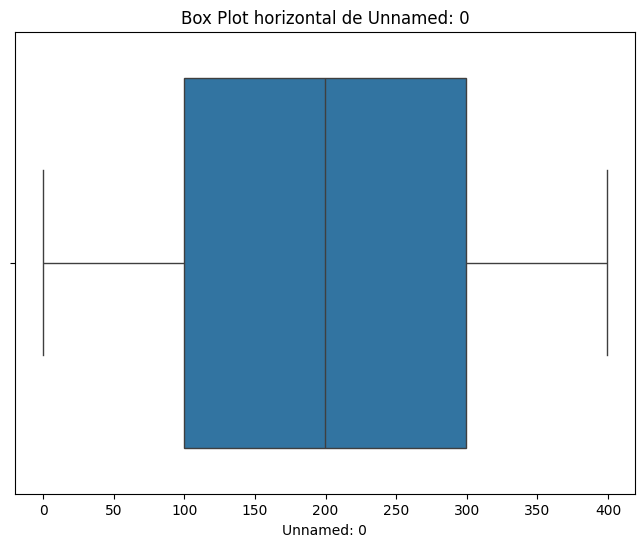

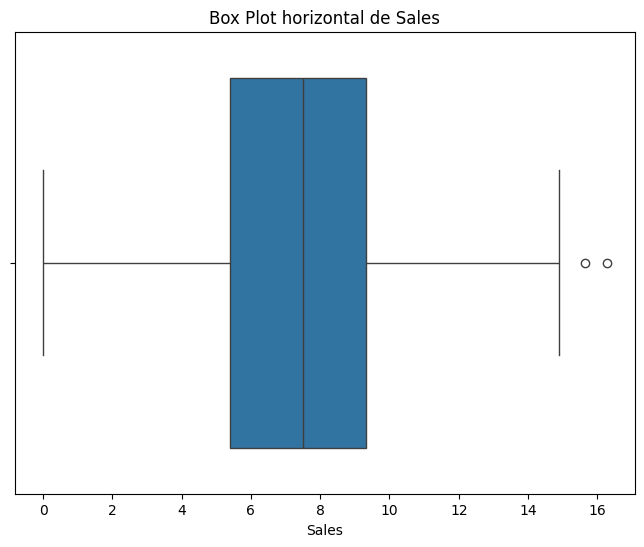

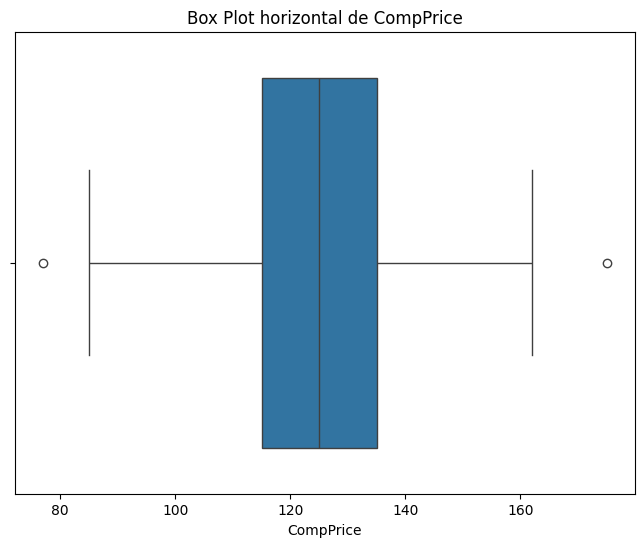

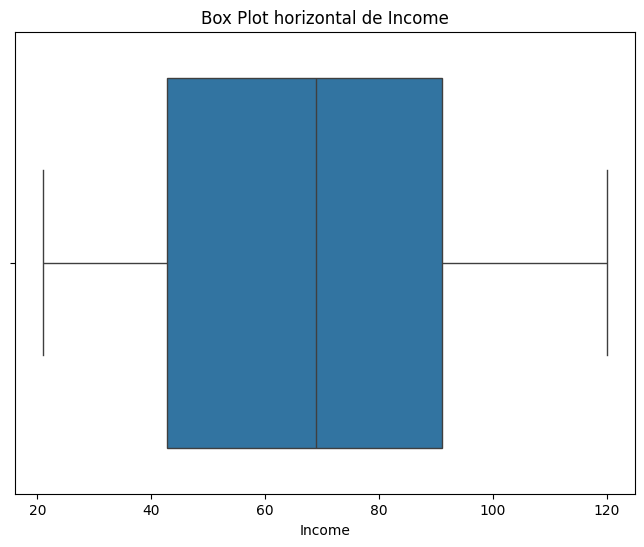

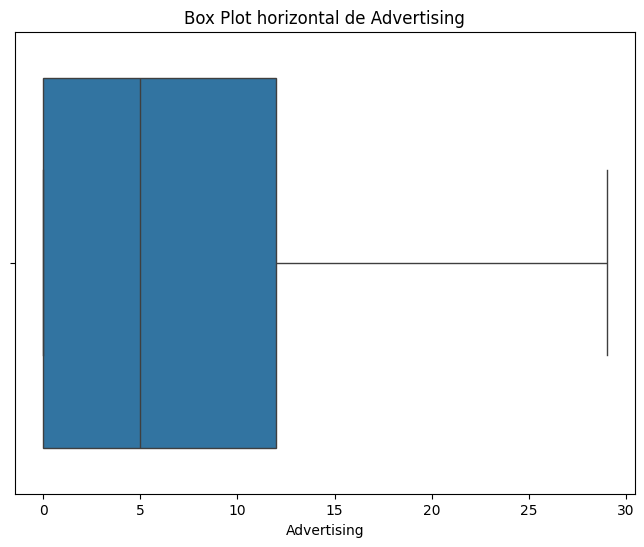

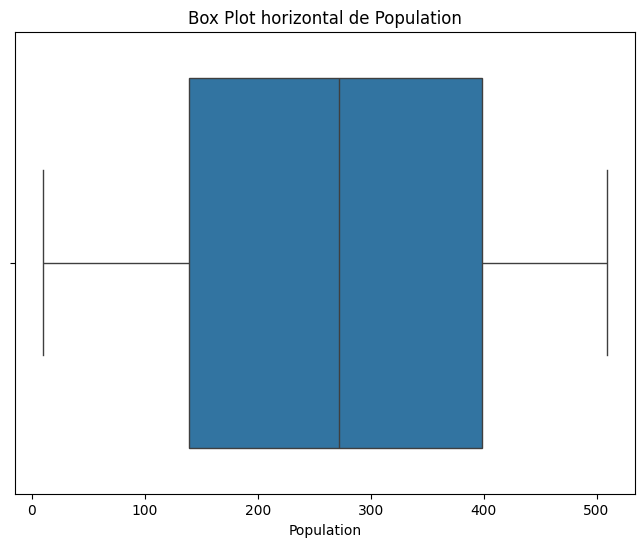

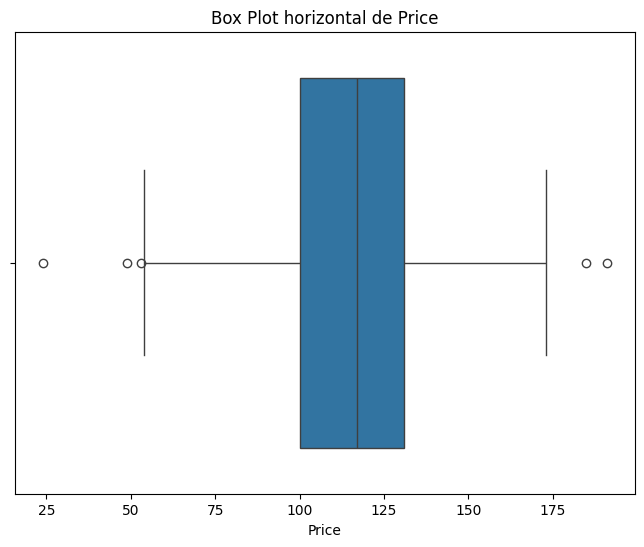

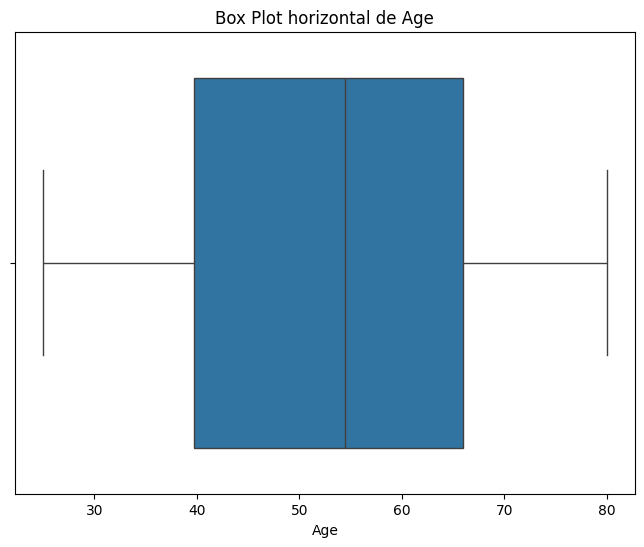

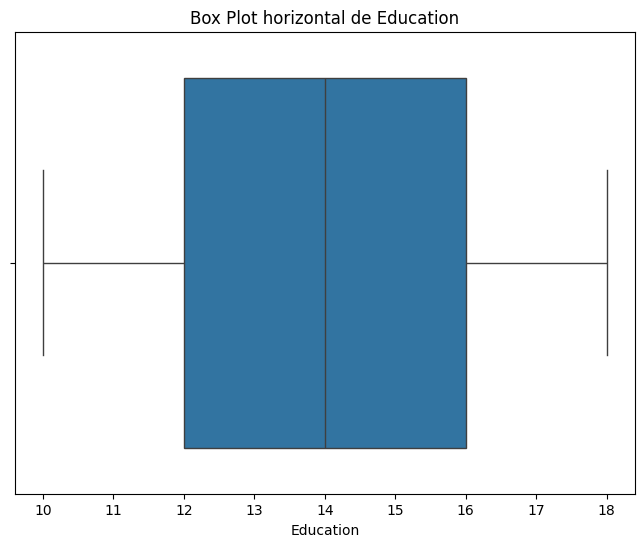

In [38]:
# Generar Box Plots para columnas numéricas
print("Generando Box Plots para columnas numéricas:") #Solo para edad
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot horizontal de {col}')
    plt.xlabel(col)
    plt.show()


Generando Count Plots verticales para columnas categóricas:


/tmp/ipykernel_2482/3916787203.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


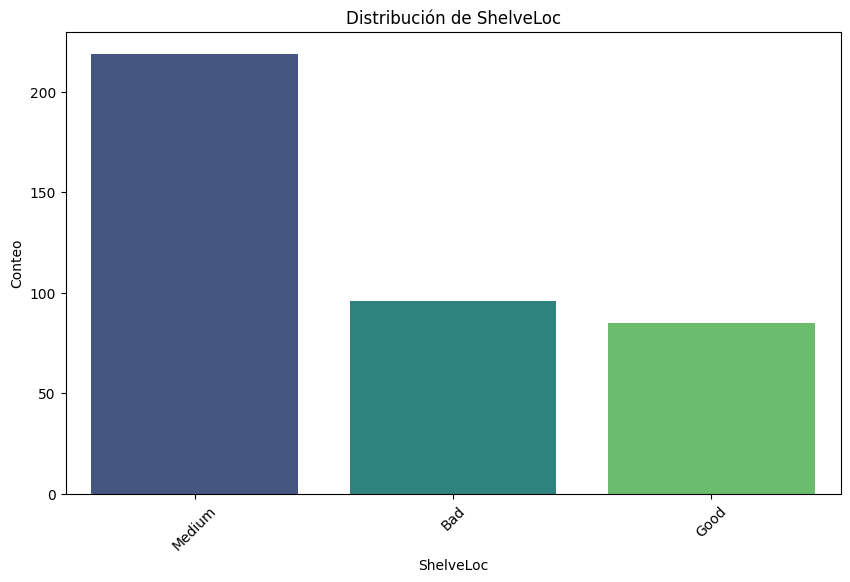

/tmp/ipykernel_2482/3916787203.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


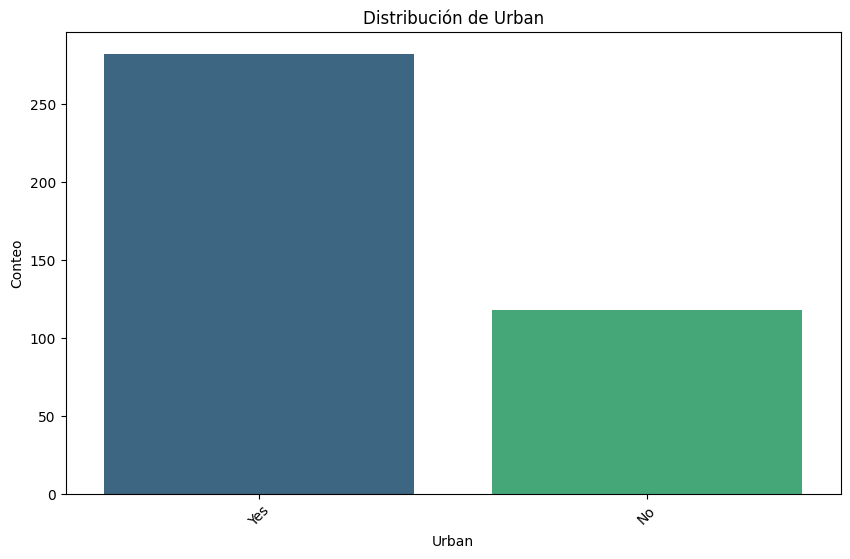

/tmp/ipykernel_2482/3916787203.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')


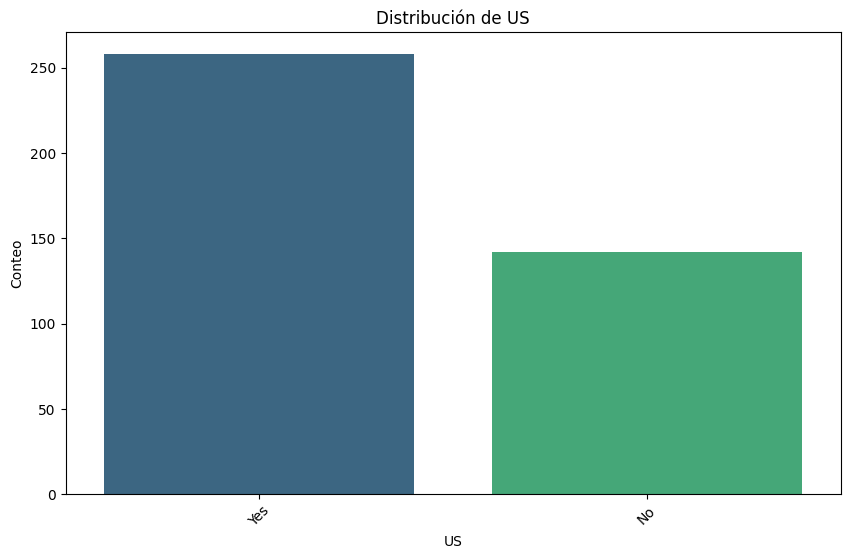

In [39]:
# Generar Count Plots verticales para columnas categóricas
print("\nGenerando Count Plots verticales para columnas categóricas:")
for col in cat_cols:
    if col not in []:  # Excluir columnas con demasiados valores únicos
        plt.figure(figsize=(10, 6))
        sns.countplot(x=df[col], order=df[col].value_counts().index, palette='viridis')
        plt.title(f'Distribución de {col}')
        plt.xlabel(col)
        plt.ylabel('Conteo')
        plt.xticks(rotation=45)
        plt.show()

In [40]:
#Carga de api ara cambio de precio de USD a pesos
url = 'https://cl.dolarapi.com/v1/cotizaciones/usd'
r = requests.get(url)
r.json()

{'moneda': 'USD',
 'nombre': 'Dólar',
 'compra': 886.95,
 'venta': 888.03,
 'ultimoCierre': 885.84,
 'fechaActualizacion': '2026-06-17T12:01:25.553Z'}